# Hospital Readmission Analysis — Diabetic Patients
**Dataset:** UCI Diabetes 130-US Hospitals (1999–2008)  
**Goal:** Identify factors associated with 30-day readmissions in diabetic patients

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

SAVE_DIR = 'visualizations/'

## 1. Data Loading & Initial Exploration

In [2]:
df = pd.read_csv('data/diabetic_data.csv')

# dataset uses '?' for missing values
df.replace('?', np.nan, inplace=True)

print('Shape:', df.shape)
print('Memory:', round(df.memory_usage(deep=True).sum() / 1024**2, 1), 'MB')

Shape: (101766, 50)


Memory: 189.6 MB


In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [5]:
df.select_dtypes(include='number').describe().round(2)

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.652016e+08,5.433040e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.026403e+08,3.869636e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.252200e+04,1.350000e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.496119e+07,2.341322e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.523890e+08,4.550514e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.302709e+08,8.754595e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.438672e+08,1.895026e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


In [6]:
print('Duplicate rows:', df.duplicated().sum())
print('Unique patients:', df['patient_nbr'].nunique())
print('Total encounters:', len(df))

Duplicate rows: 0
Unique patients: 71518
Total encounters: 101766


## 2. Data Quality Assessment
Before cleaning anything, get a full picture of what's missing or broken.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)
missing_df

,count,pct
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


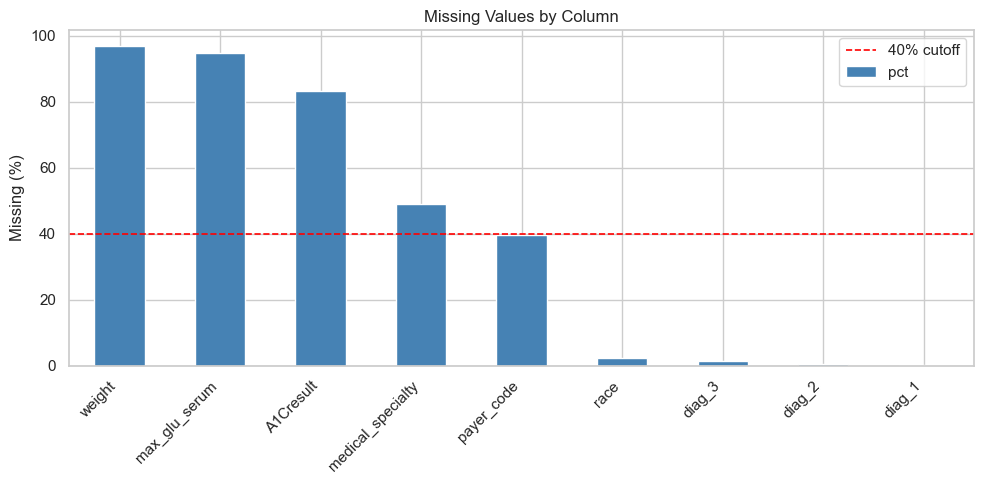

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['pct'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(40, color='red', linestyle='--', linewidth=1.2, label='40% cutoff')
ax.set_title('Missing Values by Column')
ax.set_ylabel('Missing (%)')
ax.set_xlabel('')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'missing_values.png', dpi=150)
plt.show()

In [9]:
high_missing = missing_df[missing_df['pct'] > 40].index.tolist()
print('Columns >40% missing (dropping):', high_missing)

Columns >40% missing (dropping): ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']


## 3. Data Cleaning
- Drop columns with >40% missing data
- Drop ID columns — not useful as features
- Convert age brackets to numeric midpoints
- Fill ~2% missing in `race` with mode
- Create binary `readmitted_30` target (1 = readmitted within 30 days)

In [10]:
drop_cols = high_missing + ['encounter_id', 'patient_nbr']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# binary readmission target
df_clean['readmitted_30'] = (df_clean['readmitted'] == '<30').astype(int)

# age brackets → numeric midpoints for correlation analysis
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df_clean['age_num'] = df_clean['age'].map(age_map)

# fix numeric columns that loaded as object
to_numeric = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]
for col in to_numeric:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

if 'race' in df_clean.columns:
    df_clean['race'] = df_clean['race'].fillna(df_clean['race'].mode()[0])

print('Clean shape:', df_clean.shape)
print('Remaining nulls:')
remaining = df_clean.isnull().sum()
print(remaining[remaining > 0])

Clean shape: (101766, 46)
Remaining nulls:


payer_code    40256
diag_1           21
diag_2          358
diag_3         1423
dtype: int64


In [11]:
overall_rate = df_clean['readmitted_30'].mean()
print(f'Overall 30-day readmission rate: {overall_rate:.1%}')
print(f'Readmission counts:\n{df_clean["readmitted"].value_counts()}')

Overall 30-day readmission rate: 11.2%
Readmission counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


## 4. Exploratory Data Analysis

### 4a. Readmission Rate Analysis

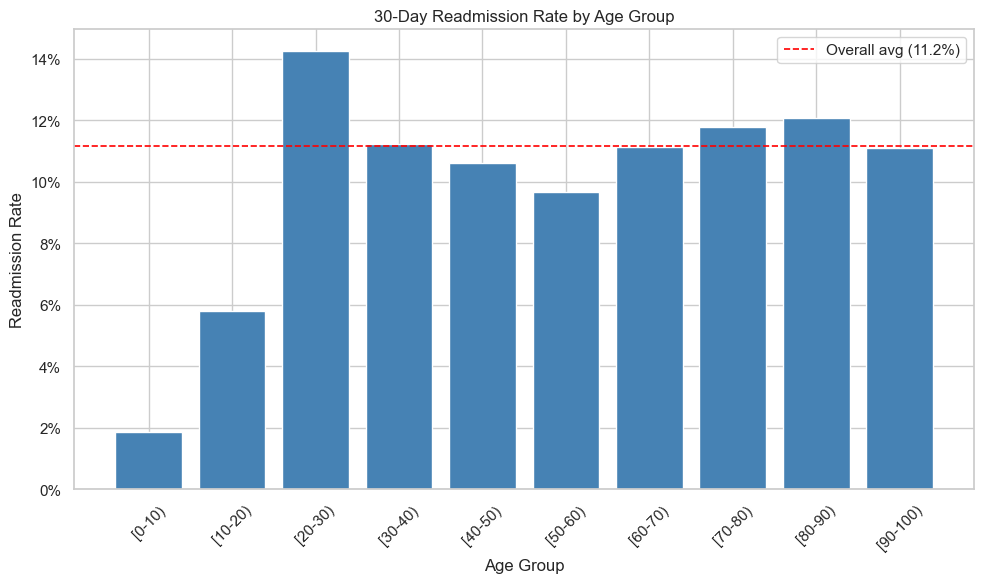

In [12]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

readmit_age = df_clean.groupby('age')['readmitted_30'].mean().reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(readmit_age.index, readmit_age.values, color='steelblue', edgecolor='white')
ax.axhline(overall_rate, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall avg ({overall_rate:.1%})')
ax.set_title('30-Day Readmission Rate by Age Group')
ax.set_ylabel('Readmission Rate')
ax.set_xlabel('Age Group')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'readmission_by_age.png', dpi=150)
plt.show()

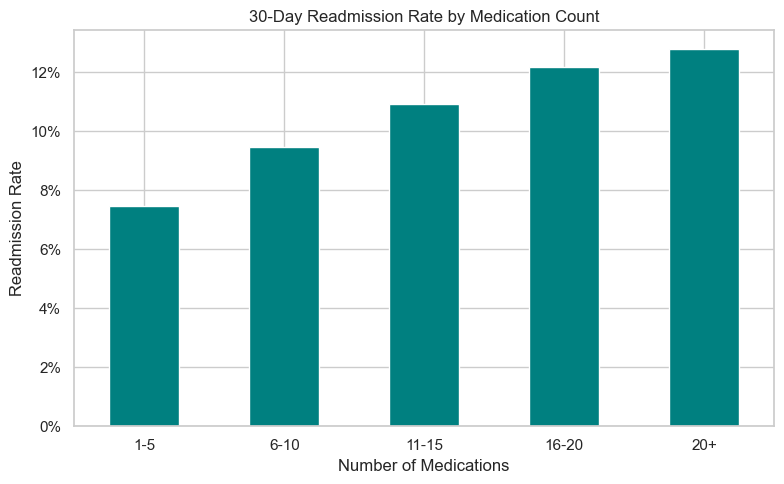

In [13]:
df_clean['med_group'] = pd.cut(df_clean['num_medications'],
                               bins=[0, 5, 10, 15, 20, 100],
                               labels=['1-5', '6-10', '11-15', '16-20', '20+'])

readmit_meds = df_clean.groupby('med_group', observed=True)['readmitted_30'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
readmit_meds.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('30-Day Readmission Rate by Medication Count')
ax.set_ylabel('Readmission Rate')
ax.set_xlabel('Number of Medications')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'readmission_by_medications.png', dpi=150)
plt.show()

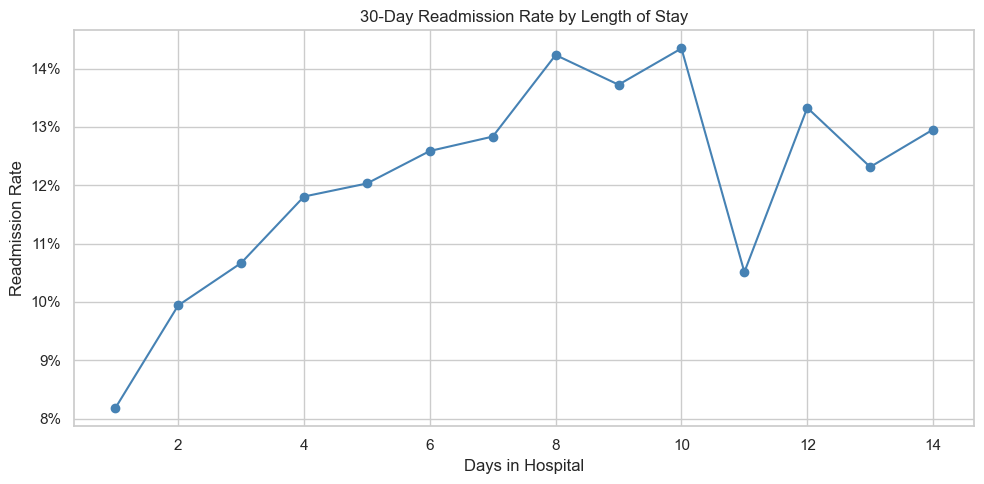

In [14]:
readmit_time = df_clean.groupby('time_in_hospital')['readmitted_30'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
readmit_time.plot(kind='line', ax=ax, marker='o', color='steelblue')
ax.set_title('30-Day Readmission Rate by Length of Stay')
ax.set_ylabel('Readmission Rate')
ax.set_xlabel('Days in Hospital')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig(SAVE_DIR + 'readmission_by_los.png', dpi=150)
plt.show()

### 4b. Clinical Patterns

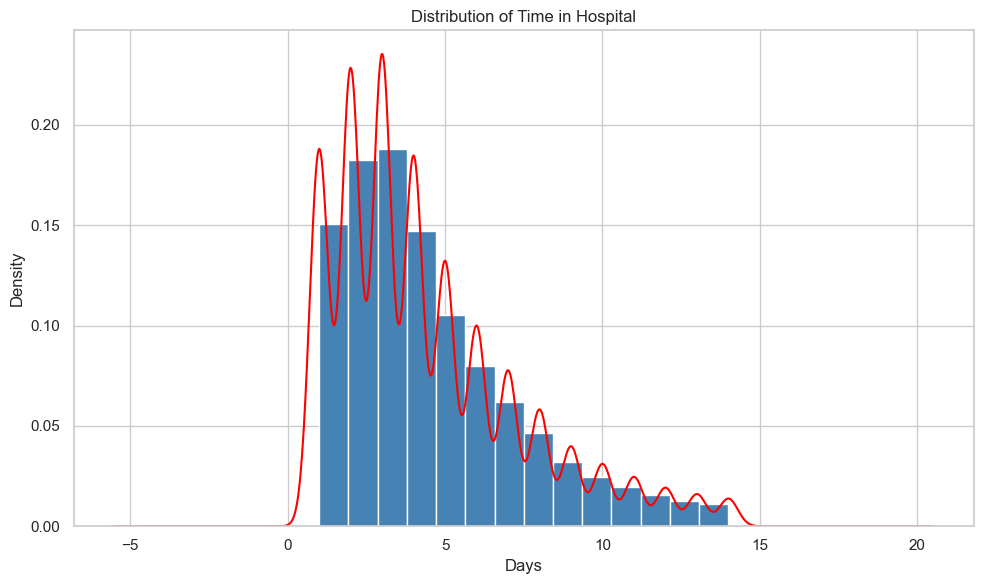

count    101766.00
mean          4.40
std           2.99
min           1.00
25%           2.00
50%           4.00
75%           6.00
max          14.00
Name: time_in_hospital, dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
df_clean['time_in_hospital'].plot(kind='hist', bins=14, ax=ax,
                                  color='steelblue', edgecolor='white', density=True)
df_clean['time_in_hospital'].plot(kind='kde', ax=ax, color='red', linewidth=1.5)
ax.set_title('Distribution of Time in Hospital')
ax.set_xlabel('Days')
ax.set_ylabel('Density')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'los_distribution.png', dpi=150)
plt.show()

print(df_clean['time_in_hospital'].describe().round(2))

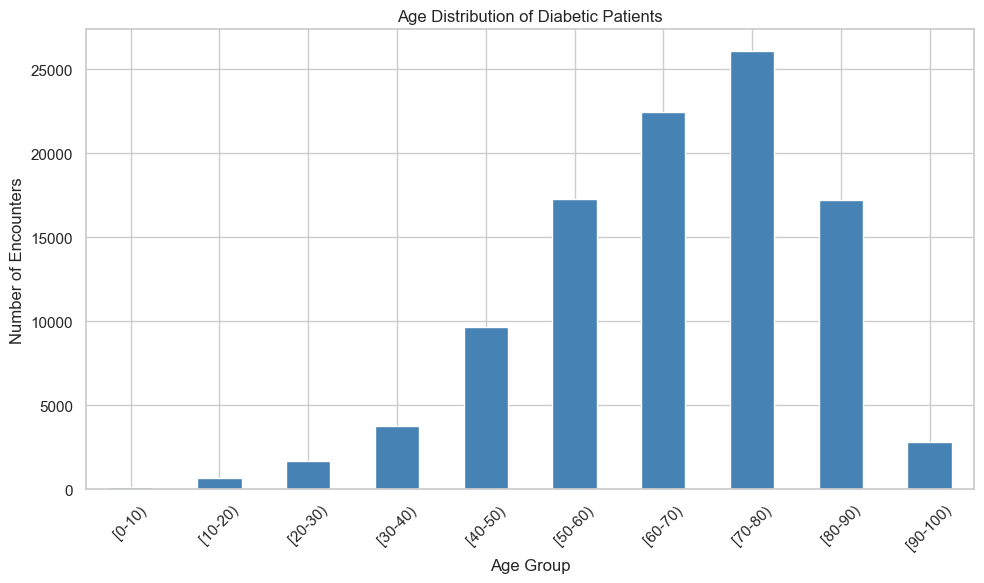

In [16]:
age_counts = df_clean['age'].value_counts().reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 6))
age_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Age Distribution of Diabetic Patients')
ax.set_ylabel('Number of Encounters')
ax.set_xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'age_distribution.png', dpi=150)
plt.show()

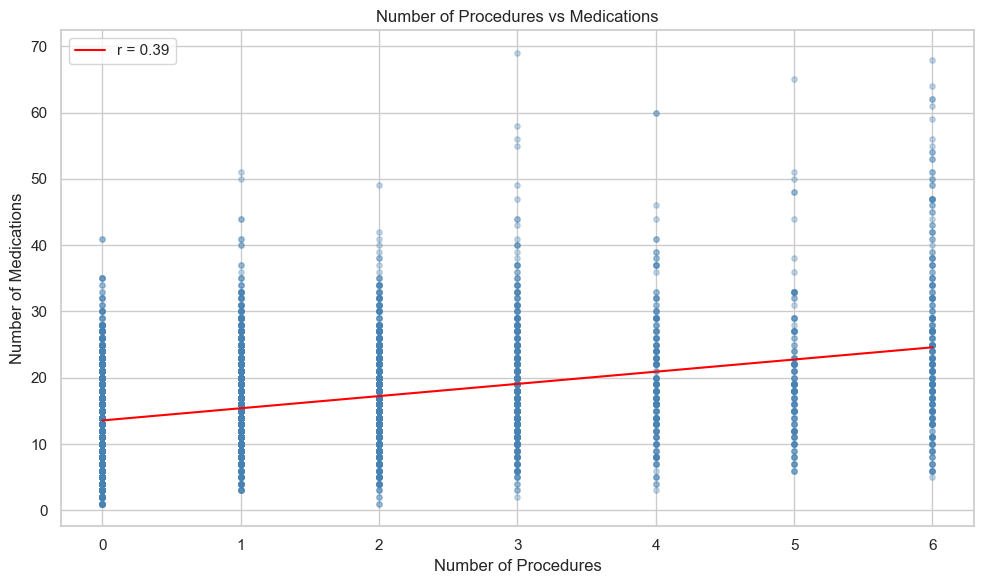

In [17]:
# scatter on a 5k sample — 100k points is unreadable
sample = df_clean.sample(5000, random_state=42)

m, b, r, _, _ = stats.linregress(df_clean['num_procedures'], df_clean['num_medications'])
x_range = np.linspace(0, df_clean['num_procedures'].max(), 100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['num_procedures'], sample['num_medications'],
           alpha=0.3, s=15, color='steelblue')
ax.plot(x_range, m * x_range + b, color='red', linewidth=1.5, label=f'r = {r:.2f}')
ax.set_title('Number of Procedures vs Medications')
ax.set_xlabel('Number of Procedures')
ax.set_ylabel('Number of Medications')
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + 'procedures_vs_medications.png', dpi=150)
plt.show()

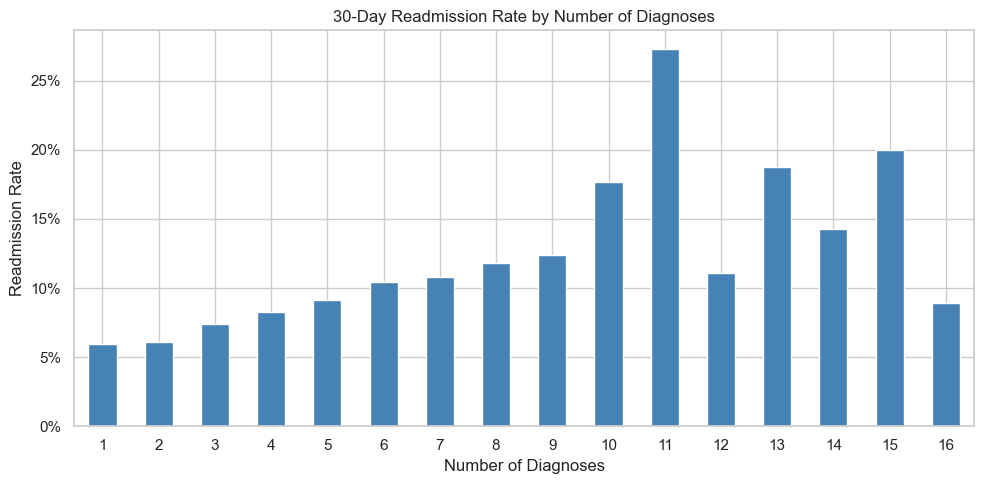

In [18]:
readmit_diag = df_clean.groupby('number_diagnoses')['readmitted_30'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
readmit_diag.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('30-Day Readmission Rate by Number of Diagnoses')
ax.set_ylabel('Readmission Rate')
ax.set_xlabel('Number of Diagnoses')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'readmission_by_diagnoses.png', dpi=150)
plt.show()

### 4c. Medication Analysis

In [19]:
if 'change' in df_clean.columns:
    change_rate = df_clean.groupby('change')['readmitted_30'].mean()
    print('Readmission rate by medication change:')
    print(change_rate.apply(lambda x: f'{x:.1%}'))

if 'diabetesMed' in df_clean.columns:
    med_rate = df_clean.groupby('diabetesMed')['readmitted_30'].mean()
    print('\nReadmission rate by diabetes medication prescribed:')
    print(med_rate.apply(lambda x: f'{x:.1%}'))

Readmission rate by medication change:
change
Ch    11.8%
No    10.6%
Name: readmitted_30, dtype: object

Readmission rate by diabetes medication prescribed:
diabetesMed
No      9.6%
Yes    11.6%
Name: readmitted_30, dtype: object


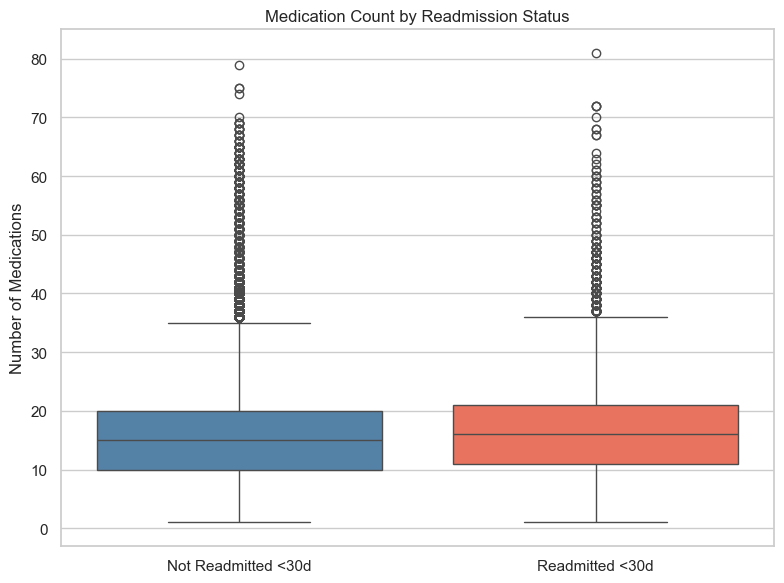

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_clean, x='readmitted_30', y='num_medications',
            ax=ax, palette=['steelblue', 'tomato'])
ax.set_xticklabels(['Not Readmitted <30d', 'Readmitted <30d'])
ax.set_title('Medication Count by Readmission Status')
ax.set_xlabel('')
ax.set_ylabel('Number of Medications')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'medications_boxplot.png', dpi=150)
plt.show()

### 4d. Top Diagnoses & Correlations

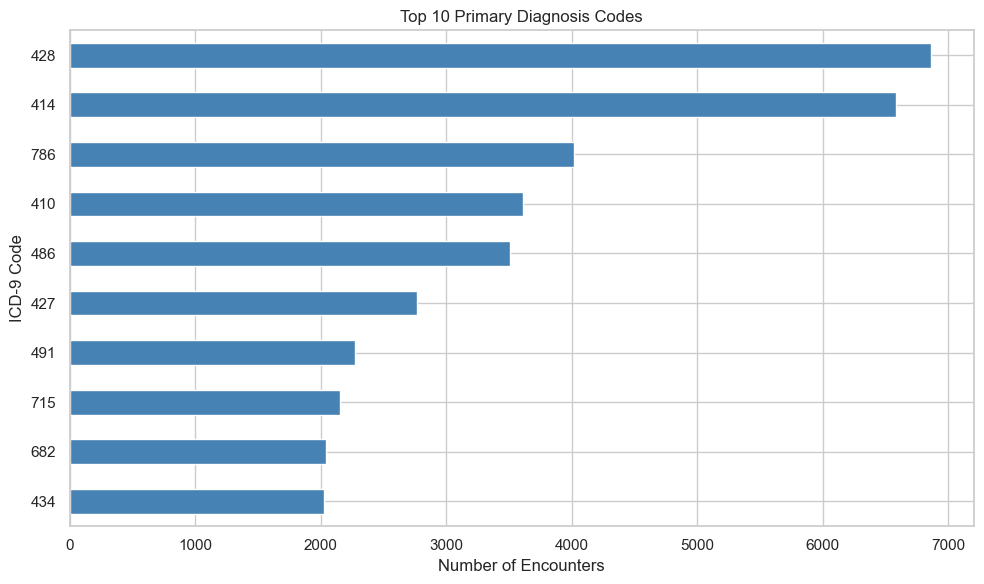

In [21]:
top_diag = df_clean['diag_1'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_diag.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Primary Diagnosis Codes')
ax.set_xlabel('Number of Encounters')
ax.set_ylabel('ICD-9 Code')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'top_diagnoses.png', dpi=150)
plt.show()

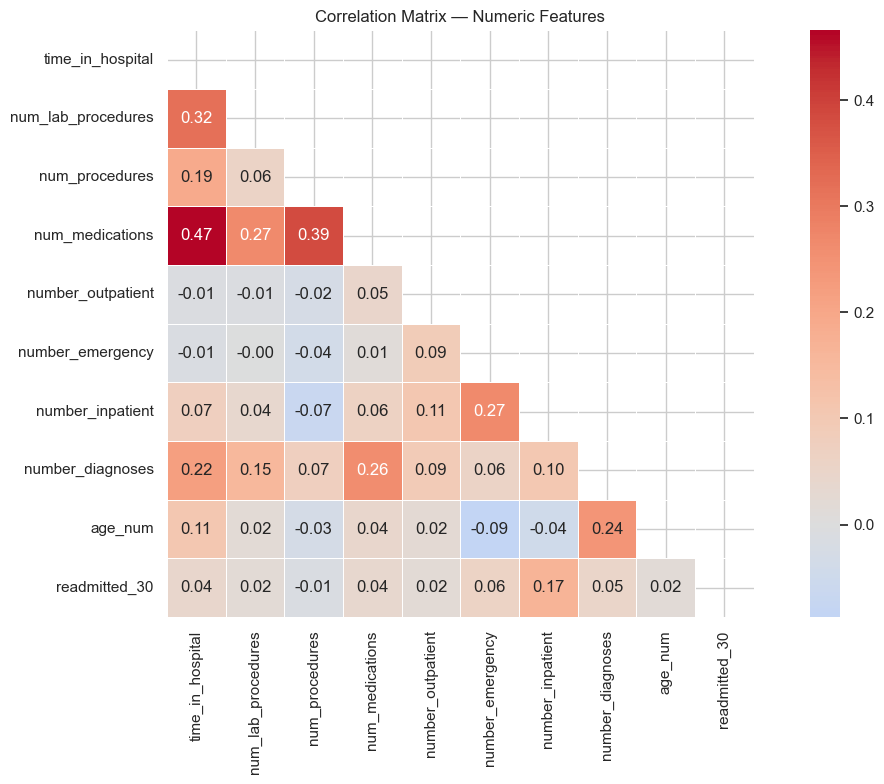

In [22]:
num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age_num', 'readmitted_30'
]
num_cols = [c for c in num_cols if c in df_clean.columns]
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'correlation_heatmap.png', dpi=150)
plt.show()

In [23]:
readmit_corr = corr['readmitted_30'].drop('readmitted_30').abs().sort_values(ascending=False)
print('Top 5 features correlated with 30-day readmission:')
print(readmit_corr.head(5).round(3))

Top 5 features correlated with 30-day readmission:
number_inpatient    0.165
number_emergency    0.061
number_diagnoses    0.050
time_in_hospital    0.044
num_medications     0.038
Name: readmitted_30, dtype: float64


## 5. Key Findings

In [24]:
print('=== Summary Stats ===')
print(f'Overall 30-day readmission rate: {df_clean["readmitted_30"].mean():.1%}')

highest_idx = readmit_age.idxmax()
print(f'Highest readmission age group: {highest_idx} ({readmit_age[highest_idx]:.1%})')

los = df_clean.groupby('readmitted_30')['time_in_hospital'].median()
print(f'Median LOS — not readmitted: {los[0]:.0f}d, readmitted: {los[1]:.0f}d')

meds = df_clean.groupby('readmitted_30')['num_medications'].mean()
print(f'Avg medications — not readmitted: {meds[0]:.1f}, readmitted: {meds[1]:.1f}')

r, p = stats.pointbiserialr(df_clean['readmitted_30'],
                             df_clean['number_inpatient'].fillna(0))
print(f'Prior inpatient visits correlation: r={r:.3f} (p={p:.2e})')

=== Summary Stats ===
Overall 30-day readmission rate: 11.2%
Highest readmission age group: [20-30) (14.2%)
Median LOS — not readmitted: 4d, readmitted: 4d
Avg medications — not readmitted: 15.9, readmitted: 16.9
Prior inpatient visits correlation: r=0.165 (p=0.00e+00)


## Summary

**Strongest predictor:** Prior inpatient visits — patients who've been hospitalized before are much more likely to come back within 30 days.  

**Medication count:** Higher medication counts correlate with readmission. This reflects disease complexity more than medications being the cause.  

**Age:** The middle-aged to elderly (50–80) make up most encounters. Readmission risk peaks around 60–80.  

**Time in hospital:** Slight positive trend — longer stays are weakly associated with higher readmission, again pointing to patient severity.  

**Limitations:** Data is from 1999–2008. Only captures readmissions to the *same* hospital. True readmission rate is likely higher. Class imbalance (~11% positive) would need handling for any predictive model.